# VisXAI: Tree / Tabular Path Demo

This notebook walks through VisXAI's fully-working **tree/tabular**
pipeline: Morgan fingerprints &rarr; a scikit-learn model &rarr; TreeSHAP
&rarr; a colored 2D structure. See `CAPABILITIES.md` at the repo root for
the full flowchart and architecture notes.

**Note up front:** this path produces **atom *and* bond-level attribution**
&mdash; a fingerprint bit represents a whole substructure (atoms *and* the
bonds connecting them), so `TreeSHAPExplainer` distributes each bit's SHAP
score to both, controlled by a `bond_score_mode` flag (`"duplicate"`,
the default, or `"split"`; see below).

In [1]:
from IPython.display import SVG, display
from sklearn.ensemble import RandomForestClassifier

from visxai.explainers.tree_shap import TreeSHAPExplainer
from visxai.features.fingerprints import generate_morgan_representation
from visxai.models.sklearn_wrapper import SklearnModelWrapper
from visxai.visualizers.rdkit_2d import RDKitSVGVisualizer

## The dataset

A tiny, fully synthetic 5-molecule dataset (the same one used in
`tests/test_tree_shap.py`, kept in sync here so the demo mirrors an
already-tested pipeline):

| SMILES | Molecule | Label |
|---|---|---|
| `CCO` | ethanol | 0 |
| `c1ccccc1` | benzene | 1 |
| `CC(=O)O` | acetic acid | 0 |
| `CN1CCCC1` | pyrrolidine | 1 |
| `CC(=O)Oc1ccccc1C(=O)O` | aspirin | 1 |

The labels are arbitrary (this is a toy dataset, not a real
structure-activity dataset) but give the classifier *some* structure to
key off so the resulting SHAP explanation isn't degenerate.

In [2]:
_SMILES = [
    "CCO",
    "c1ccccc1",
    "CC(=O)O",
    "CN1CCCC1",
    "CC(=O)Oc1ccccc1C(=O)O",
]
_LABELS = [0, 1, 0, 1, 1]
_N_BITS = 2048

fingerprint_matrix = [
    generate_morgan_representation(smi, n_bits=_N_BITS).fingerprint_array
    for smi in _SMILES
]

clf = RandomForestClassifier(n_estimators=10, random_state=42)
clf.fit(fingerprint_matrix, _LABELS)
print("Trained RandomForestClassifier on", len(_SMILES), "molecules.")

Trained RandomForestClassifier on 5 molecules.


[17:17:06] DEPRECATION WARNING: please use MorganGenerator
[17:17:06] DEPRECATION WARNING: please use MorganGenerator
[17:17:06] DEPRECATION WARNING: please use MorganGenerator
[17:17:06] DEPRECATION WARNING: please use MorganGenerator
[17:17:06] DEPRECATION WARNING: please use MorganGenerator


## Explaining aspirin

Aspirin (`CC(=O)Oc1ccccc1C(=O)O`) is the largest molecule in the dataset
(13 heavy atoms) and the most visually interesting to explain.

[17:17:06] DEPRECATION WARNING: please use MorganGenerator


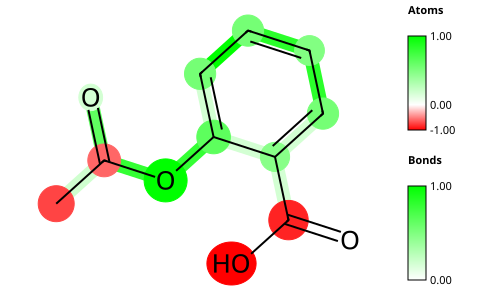

In [3]:
mol_rep = generate_morgan_representation("CC(=O)Oc1ccccc1C(=O)O", n_bits=_N_BITS)
wrapper = SklearnModelWrapper(clf)
explanation = TreeSHAPExplainer().explain(wrapper, mol_rep)

svg = RDKitSVGVisualizer().visualize(mol_rep, explanation)
display(SVG(svg))

Atoms **and bonds** are colored on a **red (negative) &ndash; white (zero) &ndash;
green (positive)** gradient, showing each element's cumulative SHAP
contribution to the prediction &mdash; bonds get a score too now, since a
fingerprint bit represents a whole substructure (atoms *and* the bonds
connecting them), not just a set of atoms. `explanation.metadata` carries
the SHAP base value and the model's raw prediction:

In [4]:
print("base_value:     ", explanation.metadata["base_value"])
print("predicted_value: ", explanation.metadata["predicted_value"])
print("n bond_scores:   ", len(explanation.bond_scores), "entries (one per bond)")

base_value:      0.6000000000000001
predicted_value:  1.0
n bond_scores:    13 entries (one per bond)


### The bit &rarr; atom/bond mapping, concretely

Every active fingerprint bit corresponds to one or more circular
environments, recorded in `mol_rep.bit_info` (atom indices) and
`mol_rep.bit_bond_info` (bond indices). For Morgan, the bond indices come
straight from RDKit's own internal environment traversal rather than
being recomputed; for MACCS, they're derived by mapping each SMARTS
pattern's bonds through its substructure matches. `TreeSHAPExplainer`
takes each bit's SHAP value and, by default (`bond_score_mode="duplicate"`),
distributes it independently across both the atoms and the bonds in that
environment (`distribute_bit_score`), then sums contributions per
atom/bond. Here's one active bit's underlying atom *and* bond
environments, next to its final per-atom and per-bond score
contributions:

In [5]:
import numpy as np

active_bits = np.flatnonzero(mol_rep.fingerprint_array)
example_bit = next(b for b in active_bits if mol_rep.bit_bond_info.get(b))
print(f"bit {example_bit} -> atom environments: {mol_rep.bit_info[example_bit]}")
print(f"bit {example_bit} -> bond environments: {mol_rep.bit_bond_info[example_bit]}")

print()
print("Full atom_scores, sorted by magnitude:")
for atom_idx, score in sorted(
    explanation.atom_scores.items(), key=lambda kv: -abs(kv[1])
):
    print(f"  atom {atom_idx}: {score:+.4f}")

print()
print("Full bond_scores, sorted by magnitude:")
for bond_idx, score in sorted(
    explanation.bond_scores.items(), key=lambda kv: -abs(kv[1])
):
    print(f"  bond {bond_idx}: {score:+.4f}")

bit 389 -> atom environments: [(10, 12)]
bit 389 -> bond environments: [(11,)]

Full atom_scores, sorted by magnitude:
  atom 3: +0.0727
  atom 4: +0.0461
  atom 5: +0.0392
  atom 6: +0.0392
  atom 8: +0.0392
  atom 7: +0.0354
  atom 9: +0.0338
  atom 12: -0.0267
  atom 10: -0.0229
  atom 0: -0.0195
  atom 1: -0.0160
  atom 2: +0.0123
  atom 11: +0.0000

Full bond_scores, sorted by magnitude:
  bond 5: +0.0248
  bond 6: +0.0206
  bond 7: +0.0206
  bond 2: +0.0197
  bond 3: +0.0197
  bond 1: +0.0154
  bond 0: +0.0046
  bond 9: +0.0043
  bond 4: +0.0043
  bond 8: +0.0043
  bond 12: +0.0043
  bond 11: +0.0000
  bond 10: +0.0000


### `bond_score_mode`: duplicate vs. split

`TreeSHAPExplainer` accepts a `bond_score_mode` flag controlling how a
bit's SHAP score relates to its bond scores:

- `"duplicate"` (the default, used above) &mdash; each bit's *full* SHAP
  score is distributed independently to both its atoms and its bonds. A
  bond in a small environment often ends up with a score equal to its
  endpoint atoms'. `atom_scores` is completely unaffected by whether bond
  attribution is enabled at all.
- `"split"` &mdash; each bit's SHAP score is divided across the
  *combined* set of its unique atoms and bonds, so `atom_scores` values
  shrink to make room for `bond_scores`: `sum(atom_scores) +
  sum(bond_scores)` for a bit's contribution equals the bit's own SHAP
  score, mirroring the graph path's Integrated-Gradients-style
  completeness axiom (see `graph_demo.ipynb`) for a more direct
  side-by-side comparison.

Same molecule, same model, both modes:

duplicate mode (default):
  sum(atom_scores) = +0.2328
  sum(bond_scores) = +0.1425

split mode:
  sum(atom_scores) = +0.1686
  sum(bond_scores) = +0.0642


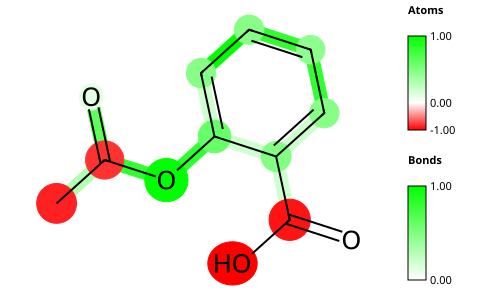

In [6]:
split_explanation = TreeSHAPExplainer(bond_score_mode="split").explain(wrapper, mol_rep)

print("duplicate mode (default):")
print(f"  sum(atom_scores) = {sum(explanation.atom_scores.values()):+.4f}")
print(f"  sum(bond_scores) = {sum(explanation.bond_scores.values()):+.4f}")

print()
print("split mode:")
print(f"  sum(atom_scores) = {sum(split_explanation.atom_scores.values()):+.4f}")
print(f"  sum(bond_scores) = {sum(split_explanation.bond_scores.values()):+.4f}")

svg_split = RDKitSVGVisualizer().visualize(mol_rep, split_explanation)
display(SVG(svg_split))

### `bond_score_mode`, concretely: one bit's contribution

The whole-molecule sums above show the two modes differ, but each sum
mixes contributions from every active bit, which obscures *why* they
differ. Isolating one specific bit makes the arithmetic exact: temporarily
restrict `bit_info`/`bit_bond_info` to just that one bit
(`dataclasses.replace`, no library changes needed) so every *other*
active bit is silently skipped as "no mapping" — the same graceful
behavior a MACCS `'?'` key gets — leaving only this bit's own contribution
in the result. Bit 1088 is used here instead of the bit from the mapping
walkthrough above, since that one happens to carry a SHAP score of
exactly `0.0` for this particular model — not a useful example for
seeing the two modes actually differ.

In [7]:
import dataclasses

mode_example_bit = 1088  # nonzero SHAP score, small clean atom+bond environment
isolated_rep = dataclasses.replace(
    mol_rep,
    bit_info={mode_example_bit: mol_rep.bit_info[mode_example_bit]},
    bit_bond_info={mode_example_bit: mol_rep.bit_bond_info[mode_example_bit]},
)
atom_ids = sorted(set().union(*mol_rep.bit_info[mode_example_bit]))
bond_ids = sorted(set().union(*mol_rep.bit_bond_info[mode_example_bit]))

isolated_dup = TreeSHAPExplainer(bond_score_mode="duplicate").explain(wrapper, isolated_rep)
isolated_split = TreeSHAPExplainer(bond_score_mode="split").explain(wrapper, isolated_rep)

print(f"bit {mode_example_bit} in isolation: {len(atom_ids)} atom(s) {atom_ids}, {len(bond_ids)} bond(s) {bond_ids}")
print()
print("duplicate mode -- full score to atoms, full score to bonds, independently:")
for a in atom_ids:
    print(f"  atom {a}: {isolated_dup.atom_scores[a]:+.4f}")
for b in bond_ids:
    print(f"  bond {b}: {isolated_dup.bond_scores[b]:+.4f}")
print(f"  (atoms sum + bonds sum = "
      f"{sum(isolated_dup.atom_scores[a] for a in atom_ids) + sum(isolated_dup.bond_scores[b] for b in bond_ids):+.4f}"
      f" -- double-counts the bit's score, not a completeness total)")

print()
print("split mode -- score divided across the combined atom+bond count:")
for a in atom_ids:
    print(f"  atom {a}: {isolated_split.atom_scores[a]:+.4f}")
for b in bond_ids:
    print(f"  bond {b}: {isolated_split.bond_scores[b]:+.4f}")
print(f"  (atoms sum + bonds sum = "
      f"{sum(isolated_split.atom_scores[a] for a in atom_ids) + sum(isolated_split.bond_scores[b] for b in bond_ids):+.4f}"
      f" -- equals the bit's own SHAP score, a real completeness total)")

bit 1088 in isolation: 4 atom(s) [5, 6, 7, 8], 3 bond(s) [5, 6, 7]

duplicate mode -- full score to atoms, full score to bonds, independently:
  atom 5: +0.0154
  atom 6: +0.0154
  atom 7: +0.0154
  atom 8: +0.0154
  bond 5: +0.0206
  bond 6: +0.0206
  bond 7: +0.0206
  (atoms sum + bonds sum = +0.1233 -- double-counts the bit's score, not a completeness total)

split mode -- score divided across the combined atom+bond count:
  atom 5: +0.0088
  atom 6: +0.0088
  atom 7: +0.0088
  atom 8: +0.0088
  bond 5: +0.0088
  bond 6: +0.0088
  bond 7: +0.0088
  (atoms sum + bonds sum = +0.0617 -- equals the bit's own SHAP score, a real completeness total)


## A second molecule, for contrast

Benzene is a deliberately tricky second example, not a straightforward
one: `TreeSHAPExplainer` gives all six aromatic carbons **exactly** the
same score, so the render below is a solid white molecule rather than a
red/green gradient. This isn't a rendering bug &mdash; benzene's D6h
symmetry means every carbon sits in an identical fingerprint environment,
so TreeSHAP's per-bit scores land on every atom equally. `RDKitSVGVisualizer`
has a documented degenerate case for exactly this
(`min_score == max_score` &rarr; solid white, legend prints `0.00`) so it
doesn't divide by zero &mdash; but note the `0.00` on the legend describes
the *normalized* value, not the raw score, which is printed below and is
not actually zero:

Raw atom_scores (all identical, not zero): {0: 0.03356481481481481, 1: 0.03356481481481481, 2: 0.03356481481481481, 3: 0.03356481481481481, 4: 0.03356481481481481, 5: 0.03356481481481481}
Raw bond_scores (all identical, not zero): {0: 0.013981481481481484, 1: 0.013981481481481484, 2: 0.013981481481481484, 3: 0.013981481481481484, 4: 0.013981481481481484, 5: 0.013981481481481484}


[17:17:06] DEPRECATION WARNING: please use MorganGenerator


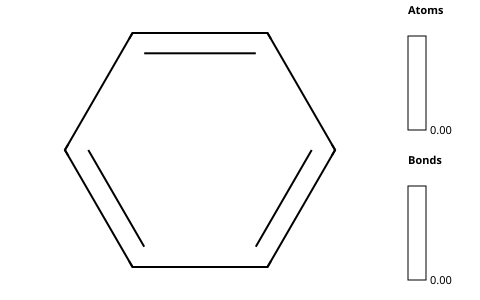

In [8]:
benzene_rep = generate_morgan_representation("c1ccccc1", n_bits=_N_BITS)
benzene_explanation = TreeSHAPExplainer().explain(wrapper, benzene_rep)

print("Raw atom_scores (all identical, not zero):", benzene_explanation.atom_scores)
print("Raw bond_scores (all identical, not zero):", benzene_explanation.bond_scores)

display(SVG(RDKitSVGVisualizer().visualize(benzene_rep, benzene_explanation)))

For the actual contrast this section originally promised &mdash; visibly different colors from atom to atom &mdash; ethanol works better than benzene precisely because it *isn't* symmetric:

Raw atom_scores: {1: -0.028055555555555556, 2: -0.13305555555555554, 0: -0.011111111111111113}


[17:17:06] DEPRECATION WARNING: please use MorganGenerator


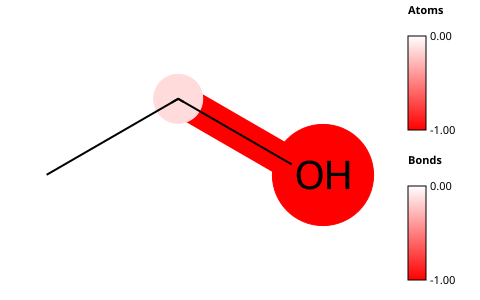

In [9]:
ethanol_rep = generate_morgan_representation("CCO", n_bits=_N_BITS)
ethanol_explanation = TreeSHAPExplainer().explain(wrapper, ethanol_rep)

print("Raw atom_scores:", ethanol_explanation.atom_scores)

display(SVG(RDKitSVGVisualizer().visualize(ethanol_rep, ethanol_explanation)))

## Next steps

- Try `generate_maccs_representation()` instead of Morgan fingerprints —
  same downstream pipeline, different bit semantics, and MACCS bond
  attribution is derived the same way (mapping each SMARTS pattern's
  bonds through its substructure matches).
- See `sequence_demo.ipynb` for the sequence-path pipeline, whose
  bond-level attribution is inherently *partial* (most SMILES bonds have
  no explicit character to measure) — contrast with this path's full
  bond coverage, and with `graph_demo.ipynb`'s Integrated-Gradients-based
  full atom+bond attribution.